# TLOB on FI-2010 — completes the baseline reproduction

Standalone run of **TLOB** (Berti & Kasneci 2025, dual-attention transformer) on FI-2010, to sit
alongside the DeepLOB / MLPLOB results from `fi2010_reproduction.ipynb`. Same data contract, same
splits, full metrics, lr=1e-4 (the paper's FI-2010 setting).

**No `mamba-ssm` needed** — TLOB is pure PyTorch, so setup is quick. Writes its own
`results/tlob_fi2010.csv`; the last cell merges it with the DeepLOB/MLPLOB CSV if you drop that in.

> **Documented deviation:** we use `seq_len=100` (our shared contract) vs the paper's FI-2010
> `seq_size=128`, so we don't expect to nail the paper's ~92.8 exactly — TLOB should, however, clearly
> beat DeepLOB/MLPLOB. Report weighted-F1 (paper-comparable) and macro-F1 (imbalanced-fair).


## 1. Runtime check

In [1]:
import platform, torch
print("Python:", platform.python_version(), "| Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU — Runtime > Change runtime type > GPU (T4).")

Python: 3.12.13 | Torch: 2.10.0+cu128 | CUDA: True
GPU: Tesla T4


## 2. Get the project code (reads the `GH_PAT` Colab secret)

In [2]:
import sys, subprocess, pathlib
REPO_URL = "https://github.com/rajjoseph48/nse-lob-capstone.git"
REPO_DIR = "nse-lob-capstone"
def _get_secret(name):
    # Kaggle -> Colab -> env var (inline: runs pre-clone, before nbenv is importable)
    try:
        from kaggle_secrets import UserSecretsClient
        v = UserSecretsClient().get_secret(name)
        if v:
            return v
    except Exception:
        pass
    try:
        from google.colab import userdata
        v = userdata.get(name)
        if v:
            return v
    except Exception:
        pass
    import os
    return os.environ.get(name, "")

GITHUB_TOKEN = _get_secret("GH_PAT")

def add_modeling(base):
    base = pathlib.Path(base)
    for cand in (base / "modeling", base):
        if (cand / "models.py").exists():
            sys.path.insert(0, str(cand.resolve()))
            return str(cand.resolve())
    return None

path = None
for c in (".", REPO_DIR, "/kaggle/working/" + REPO_DIR, "/content/" + REPO_DIR):
    path = add_modeling(c)
    if path:
        break
if not path:
    url = REPO_URL.replace("https://", f"https://{GITHUB_TOKEN}@") if GITHUB_TOKEN else REPO_URL
    subprocess.run(["git", "clone", "--depth", "1", url], check=True)
    path = add_modeling(REPO_DIR)
print("modeling/ on sys.path:", path)

Cloning into 'nse-lob-capstone'...


modeling/ on sys.path: /kaggle/working/nse-lob-capstone/modeling


## 3. Dependencies (no mamba-ssm — TLOB is pure PyTorch)

In [3]:
import importlib, subprocess, sys
for pkg in ["sklearn", "seaborn", "pandas", "matplotlib", "boto3"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        {"sklearn": "scikit-learn"}.get(pkg, pkg)])
print("dependencies ok")

dependencies ok


## 4. Get FI-2010 data (same as the reproduction notebook)
Set `DATA_DIR` if you already have it; else Kaggle (`KAGGLE_USERNAME`/`KAGGLE_KEY` Colab secrets).

In [8]:
import pathlib, zipfile

DATA_DIR = ""

def find_zscore_dir(root):
    root = pathlib.Path(root)
    if (root / "NoAuction_Zscore_Training").exists():
        return root
    for p in root.rglob("*"):
        if p.is_dir() and p.name.lower() == "noauction_zscore_training":
            return p.parent
    for p in root.rglob("*"):
        if p.is_dir() and "zscore" in p.name.lower() and "noauction" in p.name.lower():
            return p
    return None

for cand in ("/kaggle/input", "fi2010_data", "."):
    if not DATA_DIR:
        f = find_zscore_dir(cand)
        if f: DATA_DIR = str(f)
print("DATA_DIR (pre-Kaggle) =", DATA_DIR or "(empty — run the Kaggle cell)")

DATA_DIR (pre-Kaggle) = /kaggle/input/datasets/ulfricirons/fi-2010/BenchmarkDatasets/NoAuction/1.NoAuction_Zscore


**Kaggle download** (skip if `DATA_DIR` is set):

In [ ]:
KAGGLE_SLUG = "ulfricirons/fi-2010"
KAGGLE_USERNAME = ""
KAGGLE_KEY = ""
if not DATA_DIR:
    import os
    KAGGLE_USERNAME = KAGGLE_USERNAME or _get_secret("KAGGLE_USERNAME")
    KAGGLE_KEY = KAGGLE_KEY or _get_secret("KAGGLE_KEY")
    if KAGGLE_USERNAME and KAGGLE_KEY:
        os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
        os.environ["KAGGLE_KEY"] = KAGGLE_KEY
    elif not os.environ.get("KAGGLE_KEY"):
        from google.colab import files
        print("Upload kaggle.json")
        files.upload()
        !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
    !pip -q install kaggle
    !kaggle datasets download -d {KAGGLE_SLUG} -p fi2010_data --unzip
    for z in list(pathlib.Path("fi2010_data").rglob("*.zip")):
        with zipfile.ZipFile(z) as zf: zf.extractall(z.parent)
    DATA_DIR = str(find_zscore_dir("fi2010_data") or "")
assert DATA_DIR, "FI-2010 not found. Set DATA_DIR manually."
print("DATA_DIR =", DATA_DIR)

## 5. Metrics helper

In [9]:
import numpy as np, torch
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             matthews_corrcoef, confusion_matrix)
from fi2010_dataset import make_loader
from train import DEVICE

CLASS_NAMES = ["Down", "Stat", "Up"]

def collect_preds(model, ds, batch_size=256):
    model = model.to(DEVICE).eval()
    loader = make_loader(ds, batch_size=batch_size, shuffle=False)
    preds, labels = [], []
    with torch.no_grad():
        for X, y in loader:
            preds.append(model(X.to(DEVICE)).argmax(1).cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(preds), np.concatenate(labels)

def full_metrics(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2], zero_division=0)
    return {"accuracy": float(accuracy_score(y_true, y_pred)),
            "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
            "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
            "mcc": float(matthews_corrcoef(y_true, y_pred)),
            "per_class": {CLASS_NAMES[i]: {"precision": float(p[i]), "recall": float(r[i]),
                                           "f1": float(f[i])} for i in range(3)},
            "confusion": confusion_matrix(y_true, y_pred, labels=[0, 1, 2]).tolist()}

Using device: cuda


## 6. Run TLOB across horizons

TLOB × {10, 20, 50, 100}, lr=1e-4, 50 epochs w/ early stopping. Writes `results/tlob_fi2010.csv`
(resumable — completed horizons are skipped). TLOB is heavier than the CNN/MLP, so this is the slow part.

In [11]:
import time, json, pathlib, pandas as pd
from fi2010_dataset import load_fi2010
from models import build_model
from train import train, save_checkpoint

RESULTS_DIR = pathlib.Path("results"); RESULTS_DIR.mkdir(exist_ok=True)
CKPT_DIR = pathlib.Path("checkpoints/fi2010"); CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = RESULTS_DIR / "tlob_fi2010.csv"

# --- S3 sync for cross-timeout resumability (each horizon uploads as soon as it finishes;
#     a fresh session pulls prior progress and skips done horizons). Needs AWS_* secrets. ---
import os
S3_BUCKET, S3_PREFIX, S3_REGION = "lob-capstone-data", "reproduction/fi2010", "ap-south-2"
for _k in ("AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY"):
    os.environ.setdefault(_k, _get_secret(_k))
try:
    import boto3
    _s3 = boto3.client("s3", region_name=S3_REGION) if os.environ.get("AWS_SECRET_ACCESS_KEY") else None
except Exception:
    _s3 = None
if _s3 is None:
    print("No AWS creds -> S3 sync OFF (results kept locally only). Add AWS_* secrets for timeout-safety.")

def _s3_put(localpath):
    if _s3 is None:
        return
    try:
        _s3.upload_file(str(localpath), S3_BUCKET, f"{S3_PREFIX}/{localpath}")
        print(f"   ^ s3://{S3_BUCKET}/{S3_PREFIX}/{localpath}")
    except Exception as e:
        print("   (s3 put skipped)", repr(e))

def _s3_pull_csv():
    if _s3 is None:
        return
    try:
        _s3.download_file(S3_BUCKET, f"{S3_PREFIX}/{RESULTS_CSV}", str(RESULTS_CSV))
        print("Pulled existing tlob_fi2010.csv from S3 — resuming.")
    except Exception:
        pass

def run_tlob(horizon, fold=7, epochs=50, batch_size=128, seq_len=100, lr=1e-4):
    tag = f"tlob_cf{fold}_h{horizon}"
    print("=" * 70); print(" ", tag, f"(lr={lr})"); print("=" * 70)
    tr, vl, te = load_fi2010(DATA_DIR, fold=fold, horizon=horizon, seq_len=seq_len)
    model = build_model("tlob", seq_len=seq_len, n_features=40)
    n_params = sum(p.numel() for p in model.parameters())
    t0 = time.time()
    hist = train(model, tr, vl, epochs=epochs, batch_size=batch_size, lr=lr, verbose=True)
    elapsed = time.time() - t0
    y_pred, y_true = collect_preds(model, te)
    mt = full_metrics(y_true, y_pred)
    ckpt = CKPT_DIR / f"{tag}.pt"; save_checkpoint(model, str(ckpt))
    row = {"model": "tlob", "fold": fold, "horizon": horizon, "n_params": n_params,
           "best_epoch": hist["best_epoch"], "epochs_run": len(hist["val_f1"]),
           "best_val_f1": round(max(hist["val_f1"]), 4),
           "test_accuracy": round(mt["accuracy"], 4), "test_macro_f1": round(mt["macro_f1"], 4),
           "test_weighted_f1": round(mt["weighted_f1"], 4), "test_mcc": round(mt["mcc"], 4),
           "train_time_s": round(elapsed, 1), "checkpoint": str(ckpt)}
    df = pd.read_csv(RESULTS_CSV) if RESULTS_CSV.exists() else pd.DataFrame()
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    df.to_csv(RESULTS_CSV, index=False)
    metrics_json = RESULTS_DIR / f"{tag}_metrics.json"
    with open(metrics_json, "w") as fjs:
        json.dump(mt, fjs, indent=2)
    for _p in (RESULTS_CSV, ckpt, metrics_json):   # push this horizon now (timeout-safe)
        _s3_put(_p)
    print(f"  -> weighted_f1={mt['weighted_f1']:.4f}  macro_f1={mt['macro_f1']:.4f}  "
          f"acc={mt['accuracy']:.4f}  ({elapsed:.0f}s)")
    return row, mt

HORIZONS = [10, 20, 50, 100]
_s3_pull_csv()                       # resume from any prior session's progress
done = set()
if RESULTS_CSV.exists():
    done = {int(h) for h in pd.read_csv(RESULTS_CSV).horizon}
all_metrics = {}
for h in HORIZONS:
    if h in done:
        print(f"skip h{h} (already done)"); continue
    _, mt = run_tlob(h)
    all_metrics[f"tlob_h{h}"] = mt
pd.read_csv(RESULTS_CSV)

  tlob_cf7_h10 (lr=0.0001)

Loading FI-2010 | fold=CF_7 | horizon=k10 | seq_len=100
  Loading from cache: .cache_cf7.npz
  Splits → train: 229,176  val: 25,376  test: 55,379
    train labels: Down:19.9%  Stat:60.0%  Up:20.0%
    test  labels: Down:14.0%  Stat:73.3%  Up:12.7%
  epoch   1 | train_loss 0.6655 | val_loss 0.5382 | val_f1 0.8146 ← best
  epoch   5 | train_loss 0.5123 | val_loss 0.5041 | val_f1 0.8244
  epoch  10 | train_loss 0.4679 | val_loss 0.4834 | val_f1 0.8424
  Early stop at epoch 14 (best epoch 4).
   ^ s3://lob-capstone-data/reproduction/fi2010/results/tlob_fi2010.csv
   ^ s3://lob-capstone-data/reproduction/fi2010/checkpoints/fi2010/tlob_cf7_h10.pt
   ^ s3://lob-capstone-data/reproduction/fi2010/results/tlob_cf7_h10_metrics.json
  -> weighted_f1=0.8797  macro_f1=0.8109  acc=0.8791  (2467s)
  tlob_cf7_h20 (lr=0.0001)

Loading FI-2010 | fold=CF_7 | horizon=k20 | seq_len=100
  Loading from cache: .cache_cf7.npz
  Splits → train: 229,176  val: 25,376  test: 55,379
    t

,model,fold,horizon,n_params,best_epoch,epochs_run,best_val_f1,test_accuracy,test_macro_f1,test_weighted_f1,test_mcc,train_time_s,checkpoint
0,tlob,7,10,1800348,4,14,0.8467,0.8791,0.8109,0.8797,0.7195,2467.2,checkpoints/fi2010/tlob_cf7_h10.pt
1,tlob,7,20,1800348,9,19,0.7415,0.7737,0.7015,0.7734,0.5574,3349.0,checkpoints/fi2010/tlob_cf7_h20.pt
2,tlob,7,50,1800348,7,17,0.8732,0.8852,0.8752,0.8840,0.8128,2993.4,checkpoints/fi2010/tlob_cf7_h50.pt
3,tlob,7,100,1800348,4,14,0.9174,0.9246,0.9248,0.9247,0.8862,2466.3,checkpoints/fi2010/tlob_cf7_h100.pt


## 7. Acceptance / sanity

TLOB should clearly beat DeepLOB/MLPLOB and approach the paper's ~92.8 weighted-F1 (reported at
seq_size=128; we use 100). We gate loosely on weighted-F1 ≥ 85% at k=10 and report macro-F1 too.

In [12]:
res = pd.read_csv(RESULTS_CSV)
row = res[res.horizon == 10]
if len(row):
    wf1 = float(row.test_weighted_f1.iloc[0]) * 100
    mf1 = float(row.test_macro_f1.iloc[0]) * 100
    print(f"TLOB k=10 -> weighted-F1 {wf1:.2f}% (paper ~92.8 @ seq=128)  |  macro-F1 {mf1:.2f}%")
    print("SANITY:", "PASS ✓ (SOTA-range)" if wf1 >= 85 else
          "REVIEW — below 85%; check lr/epochs/seq_len deviation")
else:
    print("Run TLOB h10 first (cell 6).")

TLOB k=10 -> weighted-F1 87.97% (paper ~92.8 @ seq=128)  |  macro-F1 81.09%
SANITY: PASS ✓ (SOTA-range)


## 8. Figures + merge with DeepLOB/MLPLOB

If you drop the reproduction CSV (`fi2010_reproduction.csv`, from Drive/S3) into `results/`, this stacks
TLOB next to DeepLOB/MLPLOB for the unified FI-2010 table.

(drop fi2010_reproduction.csv into results/ to merge with DeepLOB/MLPLOB)
TLOB weighted-F1 by horizon:
         test_macro_f1  test_weighted_f1
horizon                                 
10              0.8109            0.8797
20              0.7015            0.7734
50              0.8752            0.8840
100             0.9248            0.9247


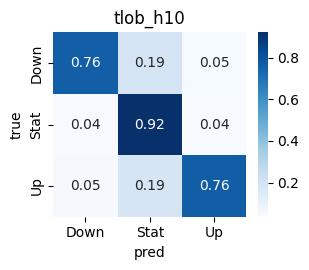

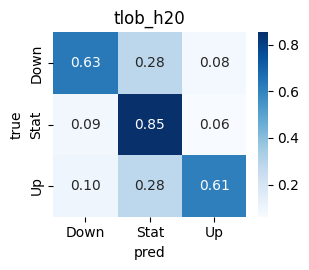

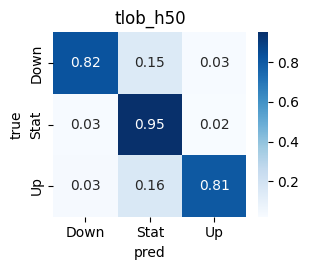

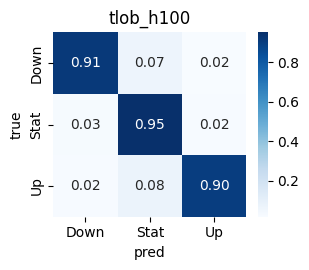

In [13]:
import matplotlib.pyplot as plt, seaborn as sns, numpy as np

res = pd.read_csv(RESULTS_CSV)
repro = RESULTS_DIR / "fi2010_reproduction.csv"
if repro.exists():
    base = pd.read_csv(repro)
    combined = pd.concat([base, res], ignore_index=True)
    print("Unified FI-2010 weighted-F1 by horizon:")
    print(combined.pivot_table(index="horizon", columns="model", values="test_weighted_f1").round(4).to_string())
else:
    print("(drop fi2010_reproduction.csv into results/ to merge with DeepLOB/MLPLOB)")
    print("TLOB weighted-F1 by horizon:")
    print(res.pivot_table(index="horizon", values=["test_weighted_f1", "test_macro_f1"]).round(4).to_string())

for key, mt in all_metrics.items():
    cm = np.array(mt["confusion"], dtype=float); cmn = cm / cm.sum(1, keepdims=True)
    plt.figure(figsize=(3.2, 2.8))
    sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(key); plt.ylabel("true"); plt.xlabel("pred"); plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"cm_{key}.png", dpi=150, bbox_inches="tight"); plt.show()

## 9. Persist results + checkpoints (S3 / Drive)

In [14]:
import os, glob
S3_BUCKET, S3_PREFIX, S3_REGION = "lob-capstone-data", "reproduction/fi2010", "ap-south-2"
for _k in ("AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY"):
    os.environ.setdefault(_k, _get_secret(_k))   # AWS creds from Kaggle/Colab secrets
try:
    import boto3
    s3 = boto3.client("s3", region_name=S3_REGION)
    for f in glob.glob("results/tlob_*") + glob.glob("checkpoints/fi2010/tlob_*"):
        key = f"{S3_PREFIX}/{f}"; s3.upload_file(f, S3_BUCKET, key); print("uploaded", key)
    print(f"Done -> s3://{S3_BUCKET}/{S3_PREFIX}/")
except Exception as e:
    print("S3 upload skipped:", repr(e))
# Drive: from google.colab import drive; drive.mount("/content/drive"); import shutil
#        shutil.copytree("results", "/content/drive/MyDrive/fi2010_repro/results", dirs_exist_ok=True)

uploaded reproduction/fi2010/results/tlob_cf7_h10_metrics.json
uploaded reproduction/fi2010/results/tlob_fi2010.csv
uploaded reproduction/fi2010/results/tlob_cf7_h50_metrics.json
uploaded reproduction/fi2010/results/tlob_cf7_h100_metrics.json
uploaded reproduction/fi2010/results/tlob_cf7_h20_metrics.json
uploaded reproduction/fi2010/checkpoints/fi2010/tlob_cf7_h100.pt
uploaded reproduction/fi2010/checkpoints/fi2010/tlob_cf7_h10.pt
uploaded reproduction/fi2010/checkpoints/fi2010/tlob_cf7_h20.pt
uploaded reproduction/fi2010/checkpoints/fi2010/tlob_cf7_h50.pt
Done -> s3://lob-capstone-data/reproduction/fi2010/
